PROSES EKSTRAKSI RGB, ECDF, DAN ANALISIS UNTUK FLOWERS102 (5 KATEGORI WARNA)

1. MENDOWNLOAD DAN MENGKATEGORIKAN FLOWERS102 BERDASARKAN 5 WARNA
Mendownload dataset Flowers102...
File data\flowers102\102flowers.tgz sudah ada
File data\flowers102\imagelabels.mat sudah ada
File data\flowers102\setid.mat sudah ada

2. MENGKATEGORIKAN GAMBAR KE DALAM 5 WARNA: merah, biru, kuning, ungu, coklat
Total images found: 8189
Mengklasifikasikan gambar ke dalam 5 kategori warna...


Categorizing by color: 100%|██████████| 3000/3000 [02:23<00:00, 20.92it/s]



📊 Distribusi gambar per kategori warna:
  red: 40 gambar
  blue: 40 gambar
  yellow: 40 gambar
  purple: 40 gambar
  brown: 21 gambar

3. ANALISIS DISTRIBUSI 5 WARNA


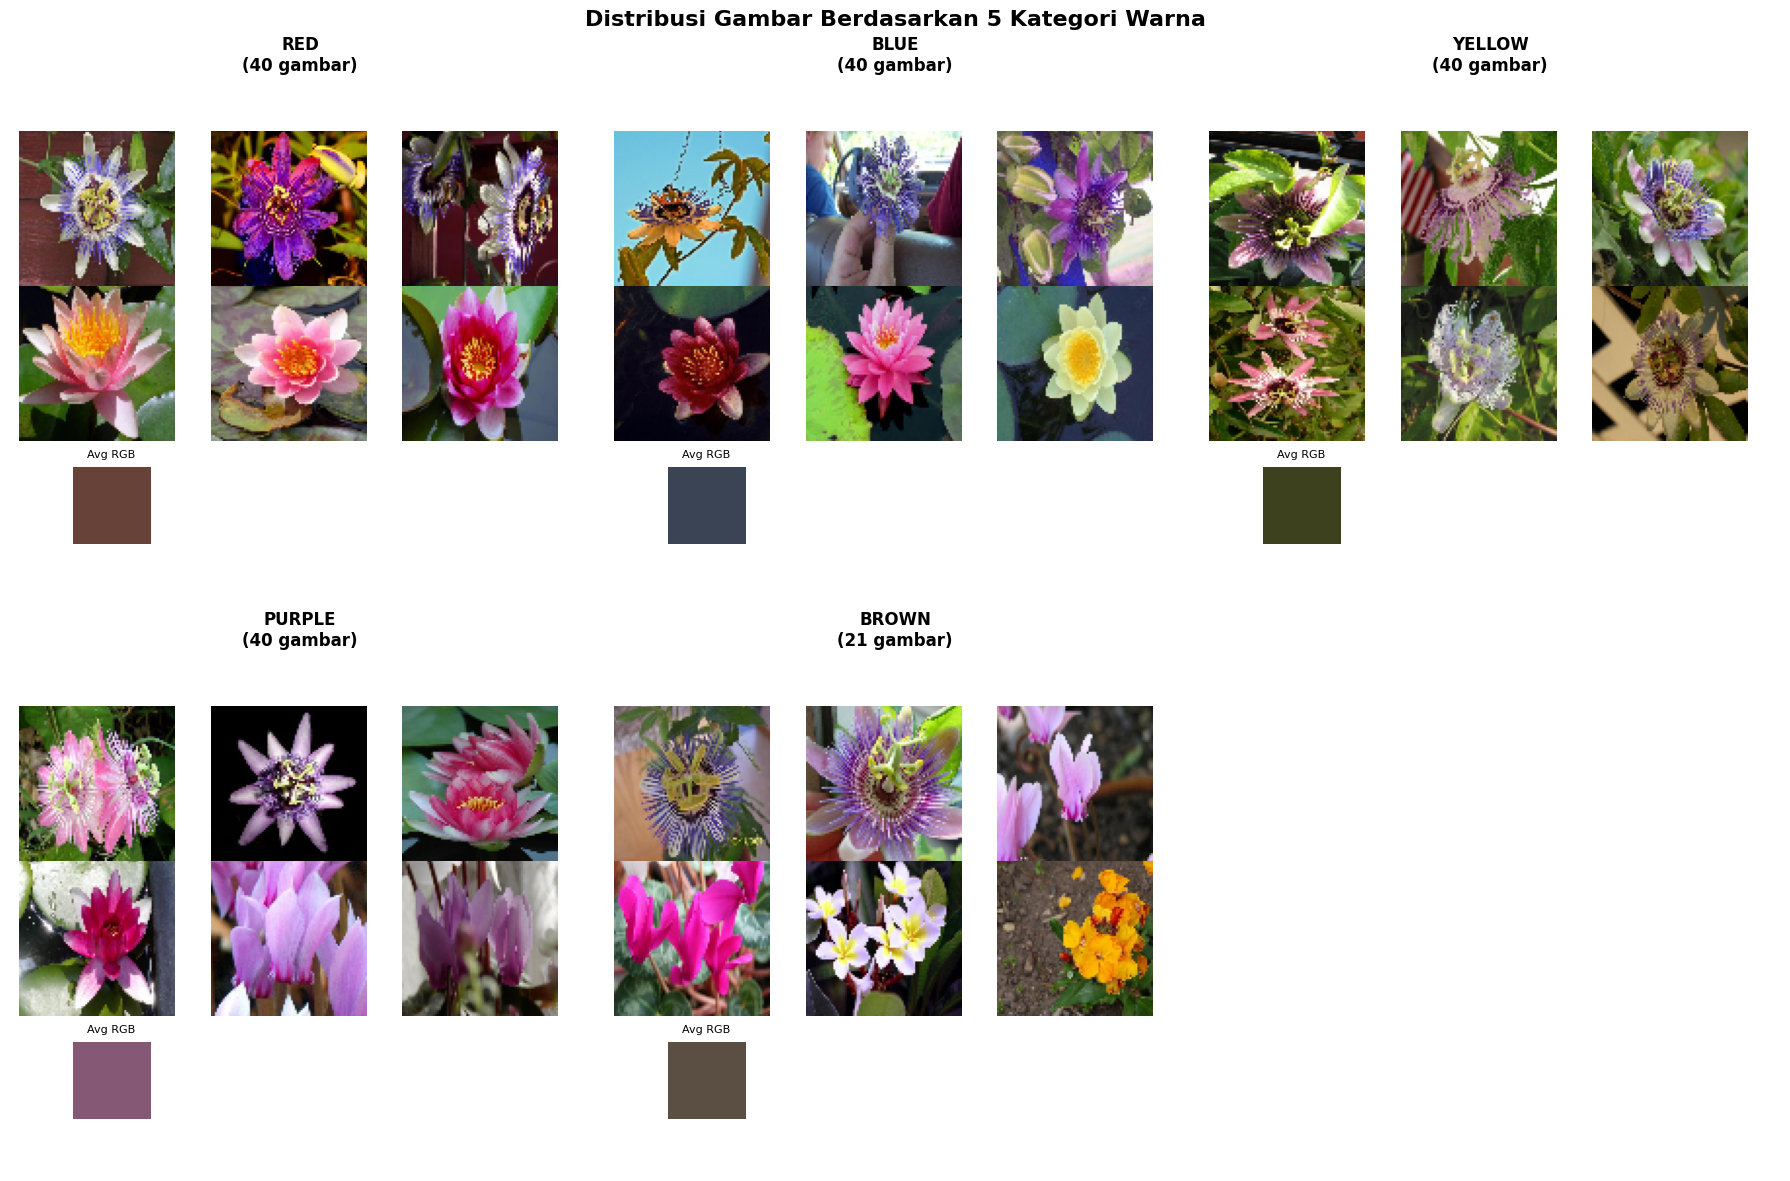


4. PROSES GAMBAR DARI 5 KATEGORI WARNA

📁 Memproses folder: data\flowers102_5colors\red (warna: red)
📁 Memproses 40 gambar dari data\flowers102_5colors\red (label: red)
✅ Berhasil memproses 40 gambar dengan label: red

📁 Memproses folder: data\flowers102_5colors\blue (warna: blue)
📁 Memproses 40 gambar dari data\flowers102_5colors\blue (label: blue)
✅ Berhasil memproses 40 gambar dengan label: blue

📁 Memproses folder: data\flowers102_5colors\yellow (warna: yellow)
📁 Memproses 40 gambar dari data\flowers102_5colors\yellow (label: yellow)
✅ Berhasil memproses 40 gambar dengan label: yellow

📁 Memproses folder: data\flowers102_5colors\purple (warna: purple)
📁 Memproses 40 gambar dari data\flowers102_5colors\purple (label: purple)
✅ Berhasil memproses 40 gambar dengan label: purple

📁 Memproses folder: data\flowers102_5colors\brown (warna: brown)
📁 Memproses 21 gambar dari data\flowers102_5colors\brown (label: brown)
✅ Berhasil memproses 21 gambar dengan label: brown

📊 TOTAL GAMBAR DIPR

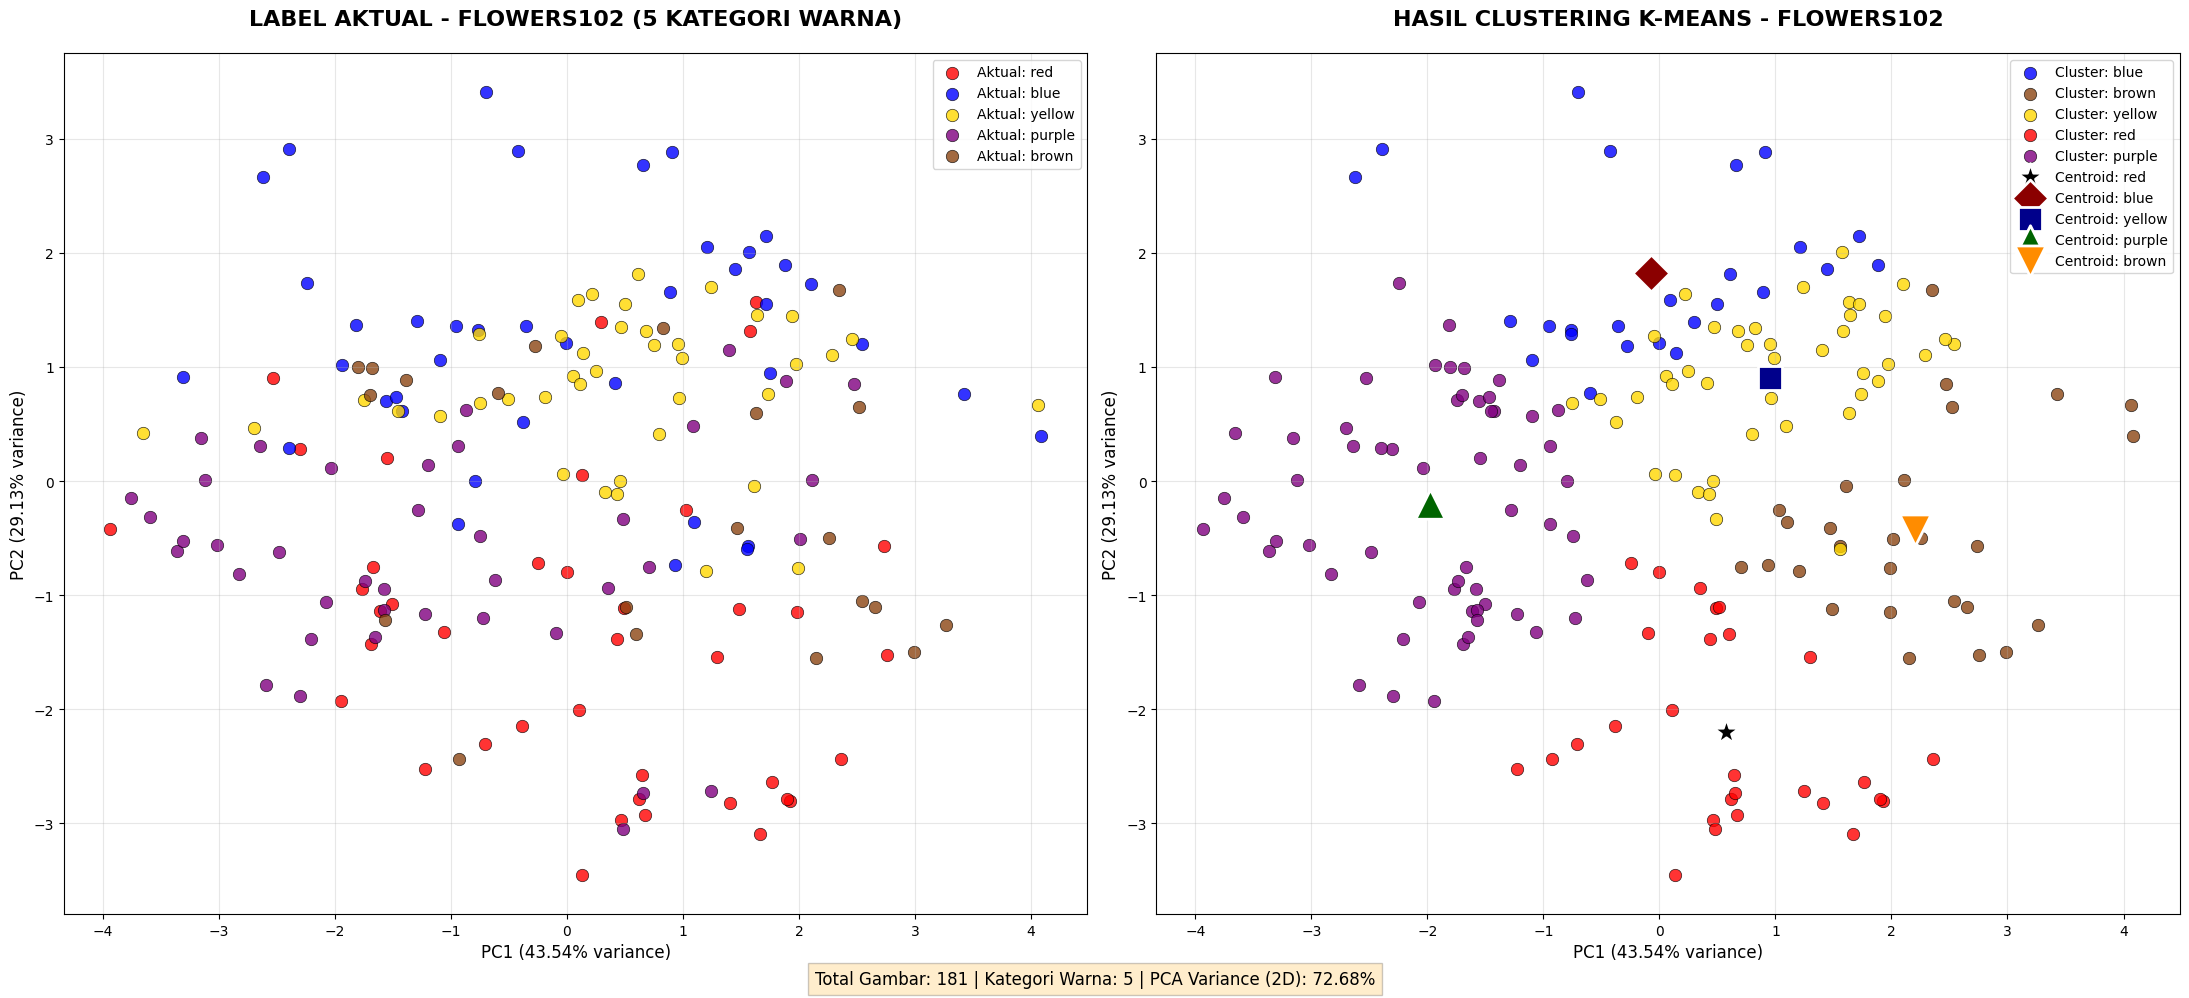


17. MENYIMPAN SEMUA HASIL ANALISIS
💾 Semua hasil disimpan ke: ./output/flowers102_5colors/analisis_pca_shap_flowers102.xlsx

🎉 PROSES SELESAI UNTUK FLOWERS102 (5 KATEGORI WARNA)!

📊 RINGKASAN HASIL:
   - Total gambar diproses: 181
   - Jumlah kategori warna: 5 (red, blue, yellow, purple, brown)
   - Jumlah fitur CDF: 7
   - Akurasi clustering: 54.70%
   - Total variance explained PCA: 100.00%
   - Top 3 fitur terpenting:
     1. R_200: 0.1763
     2. B_150: 0.1679
     3. R_150: 0.1658


In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shutil
from pathlib import Path
from tqdm import tqdm
import tarfile
import requests
from scipy.io import loadmat
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

# =============================================
# KONFIGURASI - FLOWERS102 DATASET
# =============================================
# Path untuk dataset
data_dir = "./data/flowers102"
output_dir = "./output/flowers102_5colors"
os.makedirs(output_dir, exist_ok=True)

# Output files
output_excel = f"{output_dir}/data_ekstraksi_rgb_flowers102.xlsx"
ecdf_output_csv = f"{output_dir}/data_ecdf_rgb_flowers102.csv"
ecdf_intensity_output_excel = f"{output_dir}/data_ecdf_intensitas_flowers102.xlsx"
conversion_output_excel = f"{output_dir}/data_ecdf_cdf_konversi_flowers102.xlsx"
clustering_output_excel = f"{output_dir}/hasil_clustering_flowers102.xlsx"
pca_shap_output_excel = f"{output_dir}/analisis_pca_shap_flowers102.xlsx"

p = 32  # Ukuran resize gambar: p x p

# =============================================
# FUNGSI DOWNLOAD DAN PREPROCESS FLOWERS102
# =============================================

class Flowers102Downloader:
    def __init__(self, data_dir='./data/flowers102'):
        self.data_dir = Path(data_dir)
        self.urls = {
            'images': 'http://www.robots.ox.ac.uk/~vgg/data/flowers/102/102flowers.tgz',
            'labels': 'http://www.robots.ox.ac.uk/~vgg/data/flowers/102/imagelabels.mat',
            'splits': 'http://www.robots.ox.ac.uk/~vgg/data/flowers/102/setid.mat'
        }
        
    def download_file(self, url, filename):
        """Download file dengan progress bar"""
        print(f"Downloading {url}...")
        response = requests.get(url, stream=True)
        total_size = int(response.headers.get('content-length', 0))
        
        os.makedirs(os.path.dirname(filename), exist_ok=True)
        
        with open(filename, 'wb') as f, tqdm(
            desc=os.path.basename(filename),
            total=total_size,
            unit='B',
            unit_scale=True,
            unit_divisor=1024,
        ) as bar:
            for data in response.iter_content(chunk_size=1024):
                size = f.write(data)
                bar.update(size)
    
    def download_and_extract(self):
        """Download semua file dan extract images"""
        print("Mendownload dataset Flowers102...")
        
        # Download files
        for name, url in self.urls.items():
            if name == 'images':
                filename = self.data_dir / '102flowers.tgz'
            elif name == 'labels':
                filename = self.data_dir / 'imagelabels.mat'
            else:
                filename = self.data_dir / 'setid.mat'
            
            if not os.path.exists(filename):
                self.download_file(url, filename)
            else:
                print(f"File {filename} sudah ada")
        
        # Extract images
        images_dir = self.data_dir / 'jpg'
        if not os.path.exists(images_dir):
            print("Extracting images...")
            with tarfile.open(self.data_dir / '102flowers.tgz', 'r:gz') as tar:
                tar.extractall(self.data_dir)
        
        return images_dir
    
    def load_metadata(self):
        """Load labels dan splits"""
        labels = loadmat(self.data_dir / 'imagelabels.mat')['labels'][0]
        splits = loadmat(self.data_dir / 'setid.mat')
        
        train_ids = splits['trnid'][0]
        val_ids = splits['valid'][0]
        test_ids = splits['tstid'][0]
        
        return labels, train_ids, val_ids, test_ids

def get_dominant_color_kmeans(img_path, n_clusters=3):
    """
    Mendapatkan warna dominan dengan K-means clustering
    """
    try:
        img = cv2.imread(str(img_path))
        if img is None:
            return None
        
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img, (100, 100))
        
        # Reshape untuk K-means
        pixels = img_resized.reshape(-1, 3)
        
        # Gunakan K-means
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        kmeans.fit(pixels)
        
        # Hitung persentase setiap cluster
        labels = kmeans.labels_
        cluster_counts = np.bincount(labels)
        dominant_cluster = np.argmax(cluster_counts)
        
        # Warna dominan (centroid cluster terbesar)
        dominant_color = kmeans.cluster_centers_[dominant_cluster]
        
        return dominant_color
        
    except Exception as e:
        print(f"Error processing {img_path}: {e}")
        return None

def categorize_to_5_colors(img_path):
    """
    Kategorikan gambar ke dalam 5 warna: merah, biru, kuning, ungu, coklat
    """
    dominant_color = get_dominant_color_kmeans(img_path)
    
    if dominant_color is None:
        return "unknown"
    
    R, G, B = dominant_color
    
    # Konversi ke HSV untuk deteksi warna yang lebih akurat
    hsv_color = cv2.cvtColor(np.uint8([[dominant_color]]), cv2.COLOR_RGB2HSV)[0][0]
    H, S, V = hsv_color
    
    # Aturan klasifikasi untuk 5 warna
    # 1. MERAH (H sekitar 0-10 atau 170-180, S tinggi)
    if (H <= 10 or H >= 170) and S > 80:
        return "red"
    
    # 2. BIRU (H sekitar 100-140, S tinggi)
    elif 100 <= H <= 140 and S > 60:
        return "blue"
    
    # 3. KUNING (H sekitar 20-40, S tinggi)
    elif 20 <= H <= 40 and S > 60:
        return "yellow"
    
    # 4. UNGU (H sekitar 130-170, S sedang-tinggi)
    elif 130 <= H <= 170 and S > 50:
        return "purple"
    
    # 5. COKLAT (H sekitar 10-20, S sedang, V rendah)
    elif 10 <= H <= 20 and 40 <= S <= 80 and V < 180:
        return "brown"
    
    # Jika tidak masuk kategori di atas, gunakan aturan RGB
    else:
        # Hitung rasio warna
        total = R + G + B + 0.001  # hindari pembagian 0
        
        r_ratio = R / total
        g_ratio = G / total
        b_ratio = B / total
        
        # Aturan berdasarkan rasio RGB
        if r_ratio > 0.5 and g_ratio < 0.3 and b_ratio < 0.3:
            return "red"
        elif b_ratio > 0.4 and r_ratio < 0.3:
            return "blue"
        elif r_ratio > 0.4 and g_ratio > 0.4 and b_ratio < 0.2:
            return "yellow"
        elif r_ratio > 0.3 and b_ratio > 0.3 and g_ratio < 0.3:
            return "purple"
        elif 0.2 < r_ratio < 0.4 and 0.2 < g_ratio < 0.4 and b_ratio < 0.2:
            return "brown"
        else:
            return "mixed"

def create_5color_dataset(images_dir, num_samples_per_color=40):
    """
    Buat dataset dengan 5 kategori warna
    """
    color_categories = ['red', 'blue', 'yellow', 'purple', 'brown']
    color_counts = {color: 0 for color in color_categories}
    
    # Buat folder untuk setiap kategori warna
    color_dir = Path("./data/flowers102_5colors")
    for color in color_categories:
        (color_dir / color).mkdir(parents=True, exist_ok=True)
    
    # Daftar semua gambar
    image_files = list(images_dir.glob("*.jpg"))
    print(f"Total images found: {len(image_files)}")
    
    # Kategorikan gambar
    color_images = {color: [] for color in color_categories}
    
    # Batasi jumlah gambar yang diproses
    max_images_to_process = 3000
    image_files_limited = image_files[:max_images_to_process]
    
    print("Mengklasifikasikan gambar ke dalam 5 kategori warna...")
    
    for img_path in tqdm(image_files_limited, desc="Categorizing by color"):
        # Jika semua kategori sudah cukup, berhenti
        if all(count >= num_samples_per_color for count in color_counts.values()):
            break
            
        color_category = categorize_to_5_colors(img_path)
        
        if color_category in color_categories and color_counts[color_category] < num_samples_per_color:
            # Copy gambar ke folder kategori yang sesuai
            dest_path = color_dir / color_category / img_path.name
            shutil.copy(img_path, dest_path)
            color_images[color_category].append(dest_path)
            color_counts[color_category] += 1
    
    print("\n📊 Distribusi gambar per kategori warna:")
    for color, count in color_counts.items():
        print(f"  {color}: {count} gambar")
    
    return color_dir

def analyze_color_distribution_5colors(color_dir):
    """
    Analisis dan visualisasi distribusi warna untuk 5 kategori
    """
    color_categories = ['red', 'blue', 'yellow', 'purple', 'brown']
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for idx, color in enumerate(color_categories):
        folder = color_dir / color
        images = list(folder.glob("*.jpg"))[:6]  # Ambil 6 gambar pertama
        
        if not images:
            axes[idx].text(0.5, 0.5, f"Tidak ada gambar\nuntuk {color}", 
                          ha='center', va='center', fontsize=12)
            axes[idx].set_title(f"Kategori: {color} (0 gambar)")
            axes[idx].axis('off')
            continue
        
        # Tampilkan 6 gambar pertama
        for i, img_path in enumerate(images[:6]):
            img = cv2.imread(str(img_path))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (80, 80))
            
            # Plot gambar
            row = i // 3
            col = i % 3
            ax = axes[idx].inset_axes([col * 0.33, 0.6 - row * 0.3, 0.3, 0.3])
            ax.imshow(img)
            ax.axis('off')
        
        # Hitung statistik warna untuk kategori ini
        colors_rgb = []
        for img_path in images:
            dominant_color = get_dominant_color_kmeans(img_path)
            if dominant_color is not None:
                colors_rgb.append(dominant_color)
        
        if colors_rgb:
            colors_array = np.array(colors_rgb)
            avg_color = np.mean(colors_array, axis=0)
            
            # Tampilkan warna rata-rata
            color_ax = axes[idx].inset_axes([0.1, 0.1, 0.15, 0.15])
            color_ax.imshow([[[avg_color[0]/255, avg_color[1]/255, avg_color[2]/255]]])
            color_ax.set_title(f"Avg RGB", fontsize=8)
            color_ax.axis('off')
        
        axes[idx].set_title(f"{color.upper()}\n({len(list(folder.glob('*.jpg')))} gambar)", 
                           fontsize=12, fontweight='bold')
        axes[idx].axis('off')
    
    # Kosongkan axis terakhir jika perlu
    if len(color_categories) < 6:
        axes[-1].axis('off')
    
    plt.suptitle("Distribusi Gambar Berdasarkan 5 Kategori Warna", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# =============================================
# FUNGSI UTAMA UNTUK MEMPROSES GAMBAR (SAMA)
# =============================================

def process_image(image_path, label, gambar_ke):
    """
    Memproses satu gambar: resize ke p x p, ekstrak RGB, dan simpan ke Excel
    """
    try:
        img = cv2.imread(str(image_path))
        if img is None:
            print(f"❌ Tidak bisa membaca gambar: {image_path}")
            return None
        
        # Resize gambar menjadi p x p
        img_resized = cv2.resize(img, (p, p))
        
        # Konversi BGR ke RGB
        img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
        
        # Ekstrak channel R, G, B
        R = img_rgb[:, :, 0].flatten()
        G = img_rgb[:, :, 1].flatten()
        B = img_rgb[:, :, 2].flatten()
        
        # Hitung statistik
        hasil = {
            'filename': os.path.basename(image_path),
            'gambar_ke': gambar_ke,
            'label': label,
            'p': p,
            'total_pixels': p * p,
            'R_values': R,
            'G_values': G,
            'B_values': B,
            'avg_R': np.mean(R),
            'avg_G': np.mean(G),
            'avg_B': np.mean(B),
            'min_R': np.min(R),
            'max_R': np.max(R),
            'min_G': np.min(G),
            'max_G': np.max(G),
            'min_B': np.min(B),
            'max_B': np.max(B)
        }
        
        return hasil
    except Exception as e:
        print(f"Error processing image {image_path}: {e}")
        return None

def process_all_images(folder_path, label):
    """
    Memproses semua gambar dalam folder
    """
    results = []
    
    folder_path = Path(folder_path)
    if not folder_path.exists():
        print(f"❌ Folder tidak ditemukan: {folder_path}")
        return pd.DataFrame()
    
    image_files = list(folder_path.glob("*.jpg"))
    
    if not image_files:
        print(f"❌ Tidak ada gambar ditemukan di: {folder_path}")
        return pd.DataFrame()
    
    print(f"📁 Memproses {len(image_files)} gambar dari {folder_path} (label: {label})")
    
    for i, image_file in enumerate(image_files):
        result = process_image(image_file, label, i+1)
        if result is not None:
            results.append(result)
    
    # Konversi ke DataFrame
    if results:
        df = pd.DataFrame(results)
        print(f"✅ Berhasil memproses {len(df)} gambar dengan label: {label}")
        return df
    else:
        print(f"❌ Tidak ada hasil yang berhasil diproses dari {folder_path}")
        return pd.DataFrame()

# =============================================
# FUNGSI ECDF DAN MODEL V (SAMA DENGAN SEBELUMNYA)
# =============================================

def calculate_ecdf(values):
    """Menghitung ECDF untuk suatu set nilai"""
    if len(values) == 0:
        return np.array([]), np.array([])
    
    sorted_values = np.sort(values)
    n = len(sorted_values)
    ecdf = np.arange(1, n + 1) / n
    
    return sorted_values, ecdf

def calculate_ecdf_for_image(image_data):
    """Menghitung ECDF untuk sebuah gambar"""
    filename = image_data['filename']
    j = image_data['gambar_ke']
    label = image_data['label']
    p_j = image_data['p']
    
    ecdf_data = {
        'filename': filename,
        'gambar_ke': j,
        'label': label,
        'p_j': p_j,
        'R': {'intensity': [], 'ecdf': []},
        'G': {'intensity': [], 'ecdf': []},
        'B': {'intensity': [], 'ecdf': []}
    }
    
    # Untuk setiap channel R, G, B
    for channel in ['R', 'G', 'B']:
        values = image_data[f'{channel}_values']
        
        if len(values) > 0:
            intensity, ecdf = calculate_ecdf(values)
            ecdf_data[channel]['intensity'] = intensity
            ecdf_data[channel]['ecdf'] = ecdf
    
    return ecdf_data

def calculate_all_ecdf(df_rgb):
    """Menghitung ECDF untuk semua gambar"""
    ecdf_results = {}
    
    for _, row in df_rgb.iterrows():
        ecdf_data = calculate_ecdf_for_image(row)
        ecdf_results[row['filename']] = ecdf_data
    
    return ecdf_results

def extract_ecdf_at_intensities(ecdf_data, intensities=[100, 150, 200]):
    """Mengekstrak nilai ECDF pada intensitas tertentu"""
    ecdf_intensity_data = []
    
    for filename, data in ecdf_data.items():
        j = data['gambar_ke']
        label = data['label']
        
        for channel in ['R', 'G', 'B']:
            channel_data = data[channel]
            intensity_values = channel_data['intensity']
            ecdf_values = channel_data['ecdf']
            
            if len(intensity_values) > 0:
                for intensity in intensities:
                    ecdf_val = 0.0
                    
                    if intensity < intensity_values[0]:
                        ecdf_val = 0.0
                    elif intensity >= intensity_values[-1]:
                        ecdf_val = 1.0
                    else:
                        for m in range(len(intensity_values) - 1):
                            if intensity_values[m] <= intensity < intensity_values[m + 1]:
                                ecdf_val = ecdf_values[m]
                                break
                        else:
                            ecdf_val = ecdf_values[-1] if intensity >= intensity_values[-1] else 0.0
                    
                    ecdf_intensity_data.append({
                        'filename': filename,
                        'gambar_ke': j,
                        'label': label,
                        'channel': channel,
                        'intensity_target': intensity,
                        'ecdf_value': ecdf_val
                    })
    
    return pd.DataFrame(ecdf_intensity_data)

def calculate_cdf_for_all_ecdf_intensities(df_ecdf_intensities):
    """Menghitung CDF untuk semua nilai ECDF pada intensitas tertentu"""
    cdf_data = []
    
    combinations = [
        ('R', 100), ('R', 150), ('R', 200),
        ('G', 150), ('G', 200),
        ('B', 150), ('B', 200)
    ]
    
    for channel, intensity in combinations:
        ecdf_values = df_ecdf_intensities[
            (df_ecdf_intensities['channel'] == channel) & 
            (df_ecdf_intensities['intensity_target'] == intensity)
        ]['ecdf_value'].values
        
        if len(ecdf_values) > 0:
            sorted_ecdf = np.sort(ecdf_values)
            cdf_values = np.arange(1, len(sorted_ecdf) + 1) / len(sorted_ecdf)
            
            for ecdf_val, cdf_val in zip(sorted_ecdf, cdf_values):
                cdf_data.append({
                    'channel': channel,
                    'intensity_target': intensity,
                    'ecdf_value': ecdf_val,
                    'cdf_value': cdf_val
                })
    
    return pd.DataFrame(cdf_data)

def create_mathematical_model_V_7features(df_cdf):
    """Membuat model matematis V dari data CDF intensitas dengan 7 fitur"""
    model_V = {}
    
    combinations = [
        ('R', 100), ('R', 150), ('R', 200),
        ('G', 150), ('G', 200),
        ('B', 150), ('B', 200)
    ]
    
    for channel, intensity in combinations:
        model_key = f'{channel}_{intensity}'
        channel_data = df_cdf[(df_cdf['channel'] == channel) & (df_cdf['intensity_target'] == intensity)]
        
        if not channel_data.empty:
            model_V[model_key] = {
                'ecdf_values': channel_data['ecdf_value'].values,
                'cdf_values': channel_data['cdf_value'].values
            }
            print(f"   ✅ Model untuk {model_key}: {len(channel_data)} data points")
        else:
            print(f"   ❌ Tidak ada data untuk {model_key}")
    
    print("✅ Model matematis V dengan 7 fitur berhasil dibuat")
    return model_V

def convert_ecdf_to_cdf_with_model_V(ecdf_value, model_key, model_V):
    """Mengkonversi nilai ECDF ke CDF menggunakan model matematis V"""
    if model_key not in model_V:
        return None
    
    model_data = model_V[model_key]
    ecdf_values = model_data['ecdf_values']
    cdf_values = model_data['cdf_values']
    
    if ecdf_value < ecdf_values[0] or ecdf_value > ecdf_values[-1]:
        return None
    
    idx = np.searchsorted(ecdf_values, ecdf_value, side='right') - 1
    return cdf_values[idx]

def extract_and_convert_ecdf_data_7features(ecdf_data, model_V):
    """Mengekstrak ECDF dan mengkonversinya ke CDF menggunakan model V"""
    conversion_results = []
    
    combinations = [
        ('R', 100), ('R', 150), ('R', 200),
        ('G', 150), ('G', 200),
        ('B', 150), ('B', 200)
    ]
    
    for filename, data in ecdf_data.items():
        j = data['gambar_ke']
        label = data['label']
        
        for channel, intensity in combinations:
            channel_data = data[channel]
            intensity_values = channel_data['intensity']
            ecdf_values = channel_data['ecdf']
            
            if len(intensity_values) > 0:
                model_key = f'{channel}_{intensity}'
                
                if model_key not in model_V:
                    continue
                
                ecdf_val = 0.0
                for m in range(len(intensity_values)):
                    if intensity < intensity_values[0]:
                        ecdf_val = 0.0
                        break
                    elif intensity >= intensity_values[m]:
                        if m == len(intensity_values) - 1 or intensity < intensity_values[m + 1]:
                            ecdf_val = ecdf_values[m]
                            break
                    elif intensity >= intensity_values[-1]:
                        ecdf_val = 1.0
                        break
                
                cdf_val = convert_ecdf_to_cdf_with_model_V(ecdf_val, model_key, model_V)
                
                conversion_results.append({
                    'filename': filename,
                    'gambar_ke': j,
                    'label': label,
                    'channel': channel,
                    'intensity_target': intensity,
                    'ecdf_value': ecdf_val,
                    'cdf_value': cdf_val,
                    'model_key': model_key
                })
    
    return pd.DataFrame(conversion_results)

# =============================================
# FUNGSI K-MEANS CLUSTERING UNTUK 5 KELAS
# =============================================

def prepare_features_for_clustering_7features(df_conversion):
    """Menyiapkan fitur untuk clustering dari data CDF hasil konversi"""
    features_data = []
    
    for filename in df_conversion['filename'].unique():
        file_data = df_conversion[df_conversion['filename'] == filename]
        
        feature_vector = {}
        feature_vector['filename'] = filename
        feature_vector['gambar_ke'] = file_data['gambar_ke'].iloc[0]
        feature_vector['label'] = file_data['label'].iloc[0]
        
        combinations = [
            ('R', 100), ('R', 150), ('R', 200),
            ('G', 150), ('G', 200),
            ('B', 150), ('B', 200)
        ]
        
        for channel, intensity in combinations:
            key = f"{channel}_{intensity}"
            matching_rows = file_data[
                (file_data['channel'] == channel) & 
                (file_data['intensity_target'] == intensity)
            ]
            
            if not matching_rows.empty:
                feature_vector[key] = matching_rows['cdf_value'].iloc[0]
            else:
                feature_vector[key] = 0.0
        
        features_data.append(feature_vector)
    
    df_features = pd.DataFrame(features_data)
    df_features = df_features.fillna(0)
    
    return df_features

def perform_kmeans_clustering_5classes(df_features):
    """Melakukan K-means clustering untuk 5 kelas"""
    feature_columns = [col for col in df_features.columns if col not in ['filename', 'gambar_ke', 'label']]
    X = df_features[feature_columns].values
    
    # Hitung centroid untuk setiap kelas
    centroids_dict = {}
    actual_labels = df_features['label'].unique()
    
    for label in actual_labels:
        class_data = df_features[df_features['label'] == label]
        if len(class_data) > 0:
            centroid_values = class_data[feature_columns].mean(axis=0).values
            centroids_dict[label] = centroid_values
    
    if len(centroids_dict) < 2:
        kmeans = KMeans(n_clusters=min(5, len(df_features)), random_state=42)
        labels = kmeans.fit_predict(X)
        centroids = kmeans.cluster_centers_
    else:
        initial_centroids = np.array(list(centroids_dict.values()))
        n_clusters = min(5, len(initial_centroids), len(df_features))
        
        try:
            kmeans = KMeans(
                n_clusters=n_clusters,
                init=initial_centroids[:n_clusters],
                n_init=1,
                max_iter=300,
                random_state=42
            )
            labels = kmeans.fit_predict(X)
            centroids = kmeans.cluster_centers_
        except:
            kmeans = KMeans(n_clusters=min(5, len(df_features)), random_state=42)
            labels = kmeans.fit_predict(X)
            centroids = kmeans.cluster_centers_
    
    df_features = df_features.copy()
    df_features['cluster'] = labels
    
    try:
        df_features['distance_to_centroid'] = kmeans.transform(X).min(axis=1)
    except:
        df_features['distance_to_centroid'] = 0.0
    
    # Mapping cluster ke label
    cluster_mapping = {}
    for cluster_idx in range(len(np.unique(labels))):
        if cluster_idx < len(centroids):
            cluster_center = centroids[cluster_idx]
            distances = {}
            for label, class_centroid in centroids_dict.items():
                distance = np.linalg.norm(cluster_center - class_centroid)
                distances[label] = distance
            
            if distances:
                closest_label = min(distances, key=distances.get)
                cluster_mapping[cluster_idx] = closest_label
            else:
                cluster_mapping[cluster_idx] = f'cluster_{cluster_idx}'
    
    df_features['cluster_label'] = df_features['cluster'].map(cluster_mapping)
    
    centroid_info = []
    for cluster_idx in range(len(np.unique(labels))):
        if cluster_idx in cluster_mapping:
            label = cluster_mapping[cluster_idx]
            centroid_values = centroids[cluster_idx] if cluster_idx < len(centroids) else None
            centroid_info.append({
                'cluster': cluster_idx,
                'cluster_label': label,
                'centroid_values': centroid_values
            })
    
    return df_features, kmeans, feature_columns, centroid_info

def analyze_clustering_results_5classes(df_features, df_conversion, centroid_info):
    """Menganalisis dan menampilkan hasil clustering untuk 5 kelas"""
    correct_predictions = 0
    total_predictions = len(df_features)
    
    clustering_results = []
    
    for _, row in df_features.iterrows():
        actual_label = row['label']
        predicted_label = row['cluster_label']
        is_correct = (actual_label == predicted_label)
        
        if is_correct:
            correct_predictions += 1
        
        clustering_results.append({
            'filename': row['filename'],
            'gambar_ke': row['gambar_ke'],
            'label_aktual': actual_label,
            'cluster_prediksi': row['cluster'],
            'label_prediksi': predicted_label,
            'benar': is_correct,
            'jarak_ke_centroid': row['distance_to_centroid']
        })
    
    accuracy = correct_predictions / total_predictions * 100 if total_predictions > 0 else 0
    
    print(f"\n📈 AKURASI CLUSTERING (5 KELAS): {accuracy:.2f}%")
    print(f"   Benar: {correct_predictions}/{total_predictions}")
    
    # Confusion matrix
    print("\n📊 CONFUSION MATRIX:")
    df_results = pd.DataFrame(clustering_results)
    if not df_results.empty:
        confusion_matrix = pd.crosstab(df_results['label_aktual'], df_results['label_prediksi'])
        print(confusion_matrix)
    
    return df_results, accuracy

# =============================================
# FUNGSI ANALISIS PCA DAN FEATURE IMPORTANCE
# =============================================

def detailed_pca_analysis(X, feature_names, n_components=7):
    """Melakukan analisis PCA yang detail"""
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    pca_full = PCA(n_components=n_components)
    X_pca_full = pca_full.fit_transform(X_scaled)
    
    # Variance explained
    print("\n📊 VARIANCE EXPLAINED:")
    cumulative_variance = 0
    for i, var in enumerate(pca_full.explained_variance_ratio_):
        cumulative_variance += var
        print(f"   PC{i+1:2}: {var:.4f} ({var:.2%}) | Cumulative: {cumulative_variance:.4f} ({cumulative_variance:.2%})")
    
    # Loadings analysis
    loadings_df = pd.DataFrame(
        pca_full.components_.T,
        columns=[f'PC{i+1}' for i in range(n_components)],
        index=feature_names
    )
    
    return pca_full, X_pca_full, loadings_df

def perform_feature_importance_analysis(X, y, feature_names):
    """Analisis feature importance dengan Random Forest"""
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_model.fit(X, y)
    
    rf_importance = rf_model.feature_importances_
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': rf_importance
    }).sort_values('importance', ascending=False)
    
    print("\n📊 TOP 7 FEATURE IMPORTANCE (Random Forest):")
    for i, (_, row) in enumerate(importance_df.iterrows()):
        print(f"   {i+1:2}. {row['feature']:15}: {row['importance']:.6f} ({row['importance']/importance_df['importance'].sum()*100:.1f}%)")
    
    return importance_df

def analyze_channel_intensity_importance_5colors(importance_df, feature_names):
    """Analisis importance berdasarkan channel dan intensitas untuk 5 warna"""
    print("\n🔬 ANALISIS CHANNEL DAN INTENSITY UNTUK 5 WARNA:")
    
    # Ekstrak informasi dari feature names
    channel_stats = {'R': 0, 'G': 0, 'B': 0}
    intensity_stats = {'100': 0, '150': 0, '200': 0}
    
    for _, row in importance_df.iterrows():
        feature = row['feature']
        importance = row['importance']
        
        if '_' in feature:
            channel = feature.split('_')[0]
            intensity = feature.split('_')[1]
            
            if channel in channel_stats:
                channel_stats[channel] += importance
            
            if intensity in intensity_stats:
                intensity_stats[intensity] += importance
    
    # Normalisasi
    total_channel = sum(channel_stats.values())
    total_intensity = sum(intensity_stats.values())
    
    print("\n📊 IMPORTANCE PER CHANNEL:")
    for channel, value in channel_stats.items():
        percentage = value / total_channel * 100 if total_channel > 0 else 0
        print(f"  {channel}: {value:.4f} ({percentage:.1f}%)")
    
    print("\n📊 IMPORTANCE PER INTENSITAS:")
    for intensity, value in intensity_stats.items():
        percentage = value / total_intensity * 100 if total_intensity > 0 else 0
        print(f"  {intensity}: {value:.4f} ({percentage:.1f}%)")

# =============================================
# FUNGSI UTAMA UNTUK 5 WARNA
# =============================================

def main_flowers102_5colors():
    """
    Fungsi utama untuk memproses Flowers102 dengan 5 kategori warna
    """
    print("PROSES EKSTRAKSI RGB, ECDF, DAN ANALISIS UNTUK FLOWERS102 (5 KATEGORI WARNA)")
    print("=" * 120)
    
    # 1. Download dan persiapan dataset
    print("\n1. MENDOWNLOAD DAN MENGKATEGORIKAN FLOWERS102 BERDASARKAN 5 WARNA")
    downloader = Flowers102Downloader(data_dir)
    images_dir = downloader.download_and_extract()
    
    # 2. Kategorikan berdasarkan 5 warna
    print("\n2. MENGKATEGORIKAN GAMBAR KE DALAM 5 WARNA: merah, biru, kuning, ungu, coklat")
    color_dir = create_5color_dataset(images_dir, num_samples_per_color=40)
    
    # 3. Analisis dan visualisasi distribusi warna
    print("\n3. ANALISIS DISTRIBUSI 5 WARNA")
    analyze_color_distribution_5colors(color_dir)
    
    # 4. Proses gambar dari 5 kategori warna
    print("\n4. PROSES GAMBAR DARI 5 KATEGORI WARNA")
    
    color_categories = ['red', 'blue', 'yellow', 'purple', 'brown']
    color_folders = {color: color_dir / color for color in color_categories}
    
    all_dfs = []
    
    for color, folder in color_folders.items():
        print(f"\n📁 Memproses folder: {folder} (warna: {color})")
        df_color = process_all_images(folder, color)
        if not df_color.empty:
            all_dfs.append(df_color)
        else:
            print(f"   ⚠️  Tidak ada gambar untuk kategori {color}")
    
    if not all_dfs:
        print("❌ Tidak ada data yang diproses.")
        return
    
    all_df_rgb = pd.concat(all_dfs, ignore_index=True)
    
    print(f"\n📊 TOTAL GAMBAR DIPROSES: {len(all_df_rgb)}")
    for color in color_categories:
        count = len(all_df_rgb[all_df_rgb['label'] == color])
        print(f"  - {color}: {count} gambar")
    
    # 5. Simpan data RGB
    print(f"\n5. MENYIMPAN DATA RGB KE EXCEL")
    all_df_rgb.to_excel(output_excel, index=False)
    print(f"💾 Data RGB disimpan ke: {output_excel}")
    
    # 6. Hitung ECDF untuk semua gambar
    print("\n6. MENGHITUNG ECDF UNTUK SEMUA GAMBAR")
    all_ecdf_results = calculate_all_ecdf(all_df_rgb)
    
    # 7. Ekstrak nilai ECDF pada intensitas tertentu
    print("\n7. EKSTRAKSI NILAI ECDF PADA INTENSITAS 100, 150, 200")
    df_ecdf_intensities = extract_ecdf_at_intensities(all_ecdf_results)
    df_ecdf_intensities.to_csv(ecdf_output_csv, index=False)
    print(f"💾 Data ECDF disimpan ke: {ecdf_output_csv}")
    
    # 8. Hitung CDF untuk semua nilai ECDF
    print("\n8. MENGHITUNG CDF UNTUK SEMUA NILAI ECDF")
    df_cdf = calculate_cdf_for_all_ecdf_intensities(df_ecdf_intensities)
    
    # 9. Buat model matematis V
    print("\n9. MEMBUAT MODEL MATEMATIS V DARI DATA CDF")
    model_V = create_mathematical_model_V_7features(df_cdf)
    
    # 10. Konversi ECDF ke CDF
    print("\n10. KONVERSI ECDF KE CDF MENGGUNAKAN MODEL V")
    df_conversion = extract_and_convert_ecdf_data_7features(all_ecdf_results, model_V)
    df_conversion.to_excel(conversion_output_excel, index=False)
    print(f"💾 Data konversi CDF disimpan ke: {conversion_output_excel}")
    
    # 11. Persiapan fitur untuk clustering
    print("\n11. PERSIAPAN FITUR UNTUK CLUSTERING")
    df_features = prepare_features_for_clustering_7features(df_conversion)
    
    if df_features.empty:
        print("❌ Tidak ada fitur yang dapat dipersiapkan untuk clustering!")
        return
    
    # 12. K-means clustering untuk 5 kelas
    print("\n12. K-MEANS CLUSTERING UNTUK 5 KELAS")
    df_features, kmeans, feature_columns, centroid_info = perform_kmeans_clustering_5classes(df_features)
    
    # 13. Analisis hasil clustering
    print("\n13. ANALISIS HASIL CLUSTERING")
    df_results, accuracy = analyze_clustering_results_5classes(df_features, df_conversion, centroid_info)
    
    # 14. Analisis PCA
    print("\n14. ANALISIS PCA")
    X = df_features[feature_columns].values
    pca_full, X_pca_full, loadings_df = detailed_pca_analysis(X, feature_columns)
    
    # 15. Analisis Feature Importance
    print("\n15. ANALISIS FEATURE IMPORTANCE")
    y = df_features['label'].values
    importance_df = perform_feature_importance_analysis(X, y, feature_columns)
    
    # 16. Analisis khusus untuk 5 warna
    analyze_channel_intensity_importance_5colors(importance_df, feature_columns)
    
    # 17. Visualisasi hasil
    print("\n16. VISUALISASI HASIL")
    plot_5color_results(df_features, X_pca_full, pca_full, centroid_info)
    
    # 18. Simpan semua hasil
    print(f"\n17. MENYIMPAN SEMUA HASIL ANALISIS")
    save_all_results_5colors(df_features, df_results, accuracy, pca_full, X_pca_full, 
                           loadings_df, importance_df, color_categories)
    
    print("\n" + "="*120)
    print("🎉 PROSES SELESAI UNTUK FLOWERS102 (5 KATEGORI WARNA)!")
    print("="*120)
    
    # Ringkasan akhir
    print("\n📊 RINGKASAN HASIL:")
    print(f"   - Total gambar diproses: {len(all_df_rgb)}")
    print(f"   - Jumlah kategori warna: 5 ({', '.join(color_categories)})")
    print(f"   - Jumlah fitur CDF: 7")
    print(f"   - Akurasi clustering: {accuracy:.2f}%")
    print(f"   - Total variance explained PCA: {sum(pca_full.explained_variance_ratio_):.2%}")
    print(f"   - Top 3 fitur terpenting:")
    top_features = importance_df.head(3)
    for i, (_, row) in enumerate(top_features.iterrows()):
        print(f"     {i+1}. {row['feature']}: {row['importance']:.4f}")

def plot_5color_results(df_features, X_pca, pca, centroid_info):
    """Visualisasi hasil untuk 5 warna"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))
    
    # Warna untuk plot
    colors = {
        'red': 'red',
        'blue': 'blue',
        'yellow': 'gold',
        'purple': 'purple',
        'brown': 'saddlebrown'
    }
    
    # Plot 1: Label aktual
    actual_labels = df_features['label'].unique()
    for label in actual_labels:
        mask = df_features['label'] == label
        color = colors.get(label, 'green')
        if mask.any():
            ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                       c=color, label=f'Aktual: {label}', s=80, alpha=0.8,
                       edgecolors='black', linewidth=0.5)
    
    ax1.set_title('LABEL AKTUAL - FLOWERS102 (5 KATEGORI WARNA)', 
                  fontsize=16, fontweight='bold', pad=20)
    ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
    ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Hasil clustering
    cluster_labels = df_features['cluster_label'].unique()
    
    for cluster_label in cluster_labels:
        mask = df_features['cluster_label'] == cluster_label
        color = colors.get(cluster_label, 'green')
        
        if mask.any():
            ax2.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                       c=color, label=f'Cluster: {cluster_label}', s=80, alpha=0.8,
                       edgecolors='black', linewidth=0.5)
    
    # Tandai centroid
    centroid_markers = ['*', 'D', 's', '^', 'v', 'p', 'h']
    centroid_sizes = [400, 350, 300, 450, 500]
    centroid_colors = ['black', 'darkred', 'darkblue', 'darkgreen', 'darkorange']
    
    for idx, centroid in enumerate(centroid_info):
        if centroid['centroid_values'] is not None:
            try:
                scaler = StandardScaler()
                feature_cols = [col for col in df_features.columns 
                               if col not in ['filename', 'gambar_ke', 'label', 'cluster', 'cluster_label', 'distance_to_centroid']]
                X_scaled = scaler.fit_transform(df_features[feature_cols].values)
                centroid_scaled = scaler.transform([centroid['centroid_values']])
                centroid_pca = pca.transform(centroid_scaled)[0][:2]
                
                marker = centroid_markers[idx % len(centroid_markers)]
                size = centroid_sizes[idx % len(centroid_sizes)]
                color = centroid_colors[idx % len(centroid_colors)]
                
                ax2.scatter(centroid_pca[0], centroid_pca[1], 
                           c=color, marker=marker, s=size,
                           label=f"Centroid: {centroid['cluster_label']}",
                           edgecolors='white', linewidth=2, zorder=5)
            except Exception as e:
                print(f"Error plotting centroid: {e}")
    
    ax2.set_title('HASIL CLUSTERING K-MEANS - FLOWERS102', 
                  fontsize=16, fontweight='bold', pad=20)
    ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
    ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    plt.figtext(0.5, 0.01, 
                f"Total Gambar: {len(df_features)} | Kategori Warna: 5 | PCA Variance (2D): {sum(pca.explained_variance_ratio_[:2]):.2%}",
                ha="center", fontsize=12, bbox={"facecolor":"orange", "alpha":0.2, "pad":5})
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.08)
    plt.show()

def save_all_results_5colors(df_features, df_results, accuracy, pca, X_pca, 
                            loadings_df, importance_df, color_categories):
    """Simpan semua hasil analisis untuk 5 warna"""
    
    with pd.ExcelWriter(pca_shap_output_excel) as writer:
        # Sheet 1: Fitur dan clustering
        df_features.to_excel(writer, sheet_name='Fitur_dan_Clustering', index=False)
        
        # Sheet 2: Hasil clustering
        df_results.to_excel(writer, sheet_name='Hasil_Clustering', index=False)
        
        # Sheet 3: Statistik clustering
        stats_data = [{
            'total_gambar': len(df_features),
            'benar': len(df_results[df_results['benar'] == True]),
            'salah': len(df_results[df_results['benar'] == False]),
            'akurasi': accuracy,
            'kategori_warna': ', '.join(color_categories),
            'jumlah_kategori': len(color_categories)
        }]
        pd.DataFrame(stats_data).to_excel(writer, sheet_name='Statistik', index=False)
        
        # Sheet 4: PCA Loadings
        loadings_df.to_excel(writer, sheet_name='PCA_Loadings', index=True)
        
        # Sheet 5: PCA Variance
        variance_data = pd.DataFrame({
            'Component': [f'PC{i+1}' for i in range(len(pca.explained_variance_ratio_))],
            'Variance_Explained': pca.explained_variance_ratio_,
            'Cumulative_Variance': np.cumsum(pca.explained_variance_ratio_)
        })
        variance_data.to_excel(writer, sheet_name='PCA_Variance', index=False)
        
        # Sheet 6: Feature Importance
        importance_df.to_excel(writer, sheet_name='Feature_Importance', index=False)
        
        # Sheet 7: PCA Transformed Data
        pca_data = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
        pca_data['filename'] = df_features['filename'].values
        pca_data['label'] = df_features['label'].values
        pca_data['cluster_label'] = df_features['cluster_label'].values
        pca_data.to_excel(writer, sheet_name='PCA_Transformed_Data', index=False)
        
        # Sheet 8: Confusion Matrix
        confusion_matrix = pd.crosstab(df_results['label_aktual'], df_results['label_prediksi'])
        confusion_matrix.to_excel(writer, sheet_name='Confusion_Matrix')
    
    print(f"💾 Semua hasil disimpan ke: {pca_shap_output_excel}")

# =============================================
# JALANKAN PROGRAM UTAMA
# =============================================

if __name__ == "__main__":
    # Jalankan proses utama untuk Flowers102 dengan 5 kategori warna
    main_flowers102_5colors()